<a href="https://colab.research.google.com/github/Krishnapabbu17/Wharton-DS-Project/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!git clone https://github.com/Krishnapabbu17/Wharton-DS-Project.git

Cloning into 'Wharton-DS-Project'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 47 (delta 21), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 25.35 KiB | 1.06 MiB/s, done.
Resolving deltas: 100% (21/21), done.


In [12]:
import sys
sys.path.append('/content/Wharton-DS-Project')

In [13]:
!pip install pandas openpyxl

In [14]:
!ls -lh data

total 2.6M
-rw-r--r-- 1 root root 2.4M Mar  2 02:48 'whl_2025 (1).xlsx'
-rw-r--r-- 1 root root  75K Mar  2 02:48  WHSDSC_2026_DataDictionary.xlsx
-rw-r--r-- 1 root root  50K Mar  2 02:48  WHSDSC_Rnd1_matchups.xlsx


In [15]:
!pwd

/content/Wharton-DS-Project


In [16]:
%cd /content/Wharton-DS-Project

/content/Wharton-DS-Project


In [17]:
!ls
!ls data

data  notebooks  README.md  src  Untitled4.ipynb  Wharton-DS-Project
'whl_2025 (1).xlsx'		   WHSDSC_Rnd1_matchups.xlsx
 WHSDSC_2026_DataDictionary.xlsx


In [18]:
import pandas as pd

whl_path = "data/whl_2025 (1).xlsx"
matchups_path = "data/WHSDSC_Rnd1_matchups.xlsx"
dict_path = "data/WHSDSC_2026_DataDictionary.xlsx"

# See tabs
print("WHL tabs:", pd.ExcelFile(whl_path).sheet_names)
print("Matchups tabs:", pd.ExcelFile(matchups_path).sheet_names)
print("Dictionary tabs:", pd.ExcelFile(dict_path).sheet_names)

# Load first tab of each
whl = pd.read_excel(whl_path, sheet_name=0)
matchups = pd.read_excel(matchups_path, sheet_name=0)
dictionary = pd.read_excel(dict_path, sheet_name=0)

print("WHL shape:", whl.shape)
print("Matchups shape:", matchups.shape)
print("Dictionary shape:", dictionary.shape)

print("\nWHL columns:\n", whl.columns.tolist())
print("\nMatchups columns:\n", matchups.columns.tolist())

WHL tabs: ['whl_2025']
Matchups tabs: ['matchups']
Dictionary tabs: ['dictionary', 'Ex_game1']
WHL shape: (25827, 26)
Matchups shape: (16, 4)
Dictionary shape: (26, 6)

WHL columns:
 ['game_id', 'record_id', 'home_team', 'away_team', 'went_ot', 'home_off_line', 'home_def_pairing', 'away_off_line', 'away_def_pairing', 'home_goalie', 'away_goalie', 'toi', 'home_assists', 'home_shots', 'home_xg', 'home_max_xg', 'home_goals', 'away_assists', 'away_shots', 'away_xg', 'away_max_xg', 'away_goals', 'home_penalties_committed', 'home_penalty_minutes', 'away_penalties_committed', 'away_penalty_minutes']

Matchups columns:
 ['game', 'game_id', 'home_team', 'away_team']


In [19]:
whl.head(3)

,game_id,record_id,home_team,away_team,went_ot,home_off_line,home_def_pairing,away_off_line,away_def_pairing,home_goalie,...,home_goals,away_assists,away_shots,away_xg,away_max_xg,away_goals,home_penalties_committed,home_penalty_minutes,away_penalties_committed,away_penalty_minutes
0,game_1,record_1,thailand,pakistan,0,PP_kill_dwn,PP_kill_dwn,PP_up,PP_up,player_id_142,...,0,2,9,1.4645,0.2166,1,7,14,1,2
1,game_1,record_2,thailand,pakistan,0,second_off,second_def,second_off,second_def,player_id_142,...,0,2,1,0.0928,0.0928,1,0,0,0,0
2,game_1,record_3,thailand,pakistan,0,first_off,second_def,second_off,second_def,player_id_142,...,0,0,2,0.1880,0.0940,0,0,0,0,0


In [20]:
matchups

,game,game_id,home_team,away_team
0,1,game_1,brazil,kazakhstan
1,2,game_2,netherlands,mongolia
2,3,game_3,peru,rwanda
3,4,game_4,thailand,oman
4,5,game_5,pakistan,germany
5,6,game_6,india,usa
6,7,game_7,panama,switzerland
7,8,game_8,iceland,canada
8,9,game_9,china,france
9,10,game_10,philippines,morocco


In [21]:
matchups.head(20)

,game,game_id,home_team,away_team
0,1,game_1,brazil,kazakhstan
1,2,game_2,netherlands,mongolia
2,3,game_3,peru,rwanda
3,4,game_4,thailand,oman
4,5,game_5,pakistan,germany
5,6,game_6,india,usa
6,7,game_7,panama,switzerland
7,8,game_8,iceland,canada
8,9,game_9,china,france
9,10,game_10,philippines,morocco


In [22]:
matchups.columns.tolist()

['game', 'game_id', 'home_team', 'away_team']

In [23]:
# =========================
# WHSDC 2026 — Part 1A (Stable Strategy)
# Power rankings + matchup probabilities using z-scored team strength
# =========================

!pip -q install pandas openpyxl numpy

import pandas as pd
import numpy as np

# ---------- 1) Load data ----------
whl_path = "data/whl_2025 (1).xlsx"
matchups_path = "data/WHSDSC_Rnd1_matchups.xlsx"

whl = pd.read_excel(whl_path, sheet_name=0)
matchups = pd.read_excel(matchups_path, sheet_name=0)

# normalize columns
whl.columns = [str(c).strip().lower().replace(" ", "_") for c in whl.columns]
matchups.columns = [str(c).strip().lower().replace(" ", "_") for c in matchups.columns]

# ---------- 2) Identify key columns ----------
def pick_first(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

gid = pick_first(whl, ["game_id", "gameid", "id", "match_id", "matchid"])
date_col = pick_first(whl, ["date", "game_date", "gamedate"])

home_team = pick_first(whl, ["home_team", "hometeam", "home"])
away_team = pick_first(whl, ["away_team", "awayteam", "away"])
home_goals = pick_first(whl, ["home_goals", "goals_home", "homegoal"])
away_goals = pick_first(whl, ["away_goals", "goals_away", "awaygoal"])
home_xg = pick_first(whl, ["home_xg", "xg_home", "homexg"])
away_xg = pick_first(whl, ["away_xg", "xg_away", "awayxg"])

# If no game_id column, build one from date + teams (works if those exist)
if gid is None:
    if date_col is None or home_team is None or away_team is None:
        raise ValueError("No game_id found and can't build one (need date + home_team + away_team).")
    whl["_game_id"] = (
        whl[date_col].astype(str) + "__" +
        whl[home_team].astype(str) + "__" +
        whl[away_team].astype(str)
    )
    gid = "_game_id"

needed = [gid, home_team, away_team, home_goals, away_goals, home_xg, away_xg]
if any(c is None for c in needed):
    raise ValueError(f"Missing required columns. Found: {needed}")

# ---------- 3) Make game-level table (1 row per game) ----------
games = (
    whl
    .drop_duplicates(subset=[gid])
    [[gid, home_team, away_team, home_goals, away_goals, home_xg, away_xg]]
    .copy()
)

games.columns = ["game_id", "home_team", "away_team", "home_goals", "away_goals", "home_xg", "away_xg"]

print("Games:", games.shape, "| Teams in games:", pd.unique(pd.concat([games["home_team"], games["away_team"]])).shape[0])

# ---------- 4) Build team-game rows (2 rows per game) ----------
rows = []
for _, r in games.iterrows():
    rows.append({
        "team": r["home_team"],
        "goals_for": r["home_goals"],
        "goals_against": r["away_goals"],
        "xg_for": r["home_xg"],
        "xg_against": r["away_xg"],
        "win": 1 if r["home_goals"] > r["away_goals"] else 0
    })
    rows.append({
        "team": r["away_team"],
        "goals_for": r["away_goals"],
        "goals_against": r["home_goals"],
        "xg_for": r["away_xg"],
        "xg_against": r["home_xg"],
        "win": 1 if r["away_goals"] > r["home_goals"] else 0
    })

team_games = pd.DataFrame(rows)

# ---------- 5) Team season summary ----------
team_table = (
    team_games
    .groupby("team", as_index=False)
    .agg(
        games=("win", "count"),
        wins=("win", "sum"),
        avg_goals_for=("goals_for", "mean"),
        avg_goals_against=("goals_against", "mean"),
        avg_xg_for=("xg_for", "mean"),
        avg_xg_against=("xg_against", "mean"),
    )
)

team_table["goal_diff"] = team_table["avg_goals_for"] - team_table["avg_goals_against"]
team_table["xg_diff"] = team_table["avg_xg_for"] - team_table["avg_xg_against"]
team_table["win_pct"] = team_table["wins"] / team_table["games"]

print("Teams:", len(team_table))
display(team_table.head())

# ---------- 6) Build a FAIR strength score using z-scores ----------
# z = (value - mean) / std
def zscore(s):
    s = s.astype(float)
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

team_table["z_xg"] = zscore(team_table["xg_diff"])
team_table["z_goal"] = zscore(team_table["goal_diff"])
team_table["z_win"] = zscore(team_table["win_pct"])

# You can keep equal weights (simple + defensible)
team_table["strength_score"] = (team_table["z_xg"] + team_table["z_goal"] + team_table["z_win"]) / 3.0

# Power rankings (32 teams)
power_rankings = team_table.sort_values("strength_score", ascending=False).reset_index(drop=True)
power_rankings["rank"] = power_rankings.index + 1

print("\nPower Rankings (Top 10):")
display(power_rankings[["rank", "team", "strength_score", "xg_diff", "goal_diff", "win_pct"]].head(10))

# ---------- 7) Matchup probabilities (16 matchups) ----------
# Find matchup home/away columns
m_home = pick_first(matchups, ["home_team", "hometeam", "home"])
m_away = pick_first(matchups, ["away_team", "awayteam", "away"])
if m_home is None or m_away is None:
    raise ValueError("Couldn't find home_team/away_team columns in matchups.")

m = matchups.rename(columns={m_home: "home_team", m_away: "away_team"}).copy()

strength_map = team_table.set_index("team")["strength_score"]

m["home_strength"] = m["home_team"].map(strength_map)
m["away_strength"] = m["away_team"].map(strength_map)
m["strength_diff"] = m["home_strength"] - m["away_strength"]

# Convert diff -> probability with logistic curve
# k controls spread: bigger k => more extreme probabilities
k = 1.25  # good starting value for z-score diffs
m["home_win_prob"] = 1 / (1 + np.exp(-k * m["strength_diff"]))

# Clamp to avoid silly 0/1
m["home_win_prob"] = m["home_win_prob"].clip(0.05, 0.95)

matchup_probs = m[["home_team", "away_team", "home_win_prob"]].sort_values("home_win_prob", ascending=False)

print("\nRound 1 Matchup Probabilities (Home win):")
display(matchup_probs)

# ---------- 8) Save outputs ----------
power_rankings[["rank", "team", "strength_score"]].to_csv("power_rankings_1a.csv", index=False)
matchup_probs.to_csv("round1_home_win_probs_1a.csv", index=False)

print("\nSaved:")
print(" - power_rankings_1a.csv")
print(" - round1_home_win_probs_1a.csv")

Games: (1312, 7) | Teams in games: 32
Teams: 32


,team,games,wins,avg_goals_for,avg_goals_against,avg_xg_for,avg_xg_against,goal_diff,xg_diff,win_pct
0,brazil,82,13,0.207317,0.158537,0.191237,0.143277,0.048780,0.047960,0.158537
1,canada,82,13,0.231707,0.134146,0.210430,0.104732,0.097561,0.105699,0.158537
2,china,82,9,0.170732,0.121951,0.155445,0.123012,0.048780,0.032433,0.109756
3,ethiopia,82,9,0.121951,0.134146,0.131489,0.173601,-0.012195,-0.042112,0.109756
4,france,82,7,0.134146,0.256098,0.159610,0.153349,-0.121951,0.006261,0.085366



Power Rankings (Top 10):


,rank,team,strength_score,xg_diff,goal_diff,win_pct
0,1,pakistan,2.093127,0.118399,0.182927,0.182927
1,2,canada,1.480107,0.105699,0.097561,0.158537
2,3,mexico,1.420998,0.094574,0.073171,0.170732
3,4,thailand,0.998635,0.061805,0.121951,0.121951
4,5,brazil,0.940154,0.047960,0.048780,0.158537
5,6,panama,0.855468,-0.003273,0.134146,0.146341
6,7,serbia,0.702378,0.033539,0.036585,0.146341
7,8,netherlands,0.559083,0.037467,0.073171,0.109756
8,9,india,0.499223,0.018473,0.060976,0.121951
9,10,china,0.434166,0.032433,0.048780,0.109756



Round 1 Matchup Probabilities (Home win):


,home_team,away_team,home_win_prob
0,brazil,kazakhstan,0.950000
1,netherlands,mongolia,0.950000
4,pakistan,germany,0.894049
5,india,usa,0.893677
3,thailand,oman,0.857326
10,ethiopia,saudi_arabia,0.814904
8,china,france,0.782661
2,peru,rwanda,0.771129
6,panama,switzerland,0.664167
15,indonesia,uae,0.552699



Saved:
 - power_rankings_1a.csv
 - round1_home_win_probs_1a.csv


In [24]:
# =========================
# WHSDC 2026 — Part 1B (Best Practice)
# Offensive line disparity: first_off vs second_off using TOI-weighted xG/60
# =========================

!pip -q install pandas openpyxl numpy

import pandas as pd
import numpy as np

# ---------- 1) Load data ----------
whl_path = "data/whl_2025 (1).xlsx"

whl = pd.read_excel(whl_path, sheet_name=0)
whl.columns = [str(c).strip().lower().replace(" ", "_") for c in whl.columns]

print("WHL shape:", whl.shape)

# ---------- 2) Helper: pick columns robustly ----------
def pick_first(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Identify team columns
home_team_col = pick_first(whl, ["home_team", "hometeam", "home"])
away_team_col = pick_first(whl, ["away_team", "awayteam", "away"])

# Identify xG columns (line-level xG in the matchup table)
home_xg_col = pick_first(whl, ["home_xg", "xg_home", "homexg"])
away_xg_col = pick_first(whl, ["away_xg", "xg_away", "awayxg"])

# Identify TOI column (time on ice for that matchup row)
toi_col = pick_first(whl, ["toi", "time_on_ice", "ice_time", "seconds", "sec"])

if any(c is None for c in [home_team_col, away_team_col, home_xg_col, away_xg_col, toi_col]):
    raise ValueError(
        f"Missing columns. Found home_team={home_team_col}, away_team={away_team_col}, "
        f"home_xg={home_xg_col}, away_xg={away_xg_col}, toi={toi_col}. "
        f"Columns available: {whl.columns.tolist()}"
    )

# ---------- 3) Find line label columns by detecting values like first_off/second_off ----------
def find_line_col(df, team_side):
    # team_side: "home" or "away"
    candidates = [c for c in df.columns if team_side in c and ("line" in c or "unit" in c or "pair" in c)]
    # also allow generic names
    if not candidates:
        candidates = [c for c in df.columns if ("line" in c or "unit" in c) and team_side in c]

    # if still none, brute force: any object column containing first_off/second_off
    if not candidates:
        obj_cols = [c for c in df.columns if df[c].dtype == "object"]
        for c in obj_cols:
            vals = set(df[c].dropna().astype(str).str.lower().unique().tolist())
            if "first_off" in vals or "second_off" in vals:
                candidates.append(c)

    # pick the one that actually contains first_off/second_off
    for c in candidates:
        vals = set(df[c].dropna().astype(str).str.lower().unique().tolist())
        if "first_off" in vals and "second_off" in vals:
            return c
    return None

home_line_col = find_line_col(whl, "home")
away_line_col = find_line_col(whl, "away")

if home_line_col is None or away_line_col is None:
    # Show any column that has those values to help debugging
    possible = []
    for c in whl.columns:
        if whl[c].dtype == "object":
            vals = set(whl[c].dropna().astype(str).str.lower().unique().tolist())
            if "first_off" in vals or "second_off" in vals:
                possible.append(c)
    raise ValueError(f"Could not auto-detect home/away line columns. Columns containing first_off/second_off: {possible}")

print("Using columns:")
print(" home_team:", home_team_col, "| away_team:", away_team_col)
print(" home_line:", home_line_col, "| away_line:", away_line_col)
print(" home_xg:", home_xg_col, "| away_xg:", away_xg_col)
print(" toi:", toi_col)

# ---------- 4) Convert TOI to minutes robustly ----------
toi_raw = pd.to_numeric(whl[toi_col], errors="coerce")
median_toi = float(toi_raw.dropna().median()) if toi_raw.notna().any() else np.nan

# heuristic:
# - if median TOI > 200, it's probably seconds (because >200 minutes in a matchup row is unlikely)
# - else assume minutes
if np.isnan(median_toi):
    raise ValueError("TOI column is entirely non-numeric / missing.")
toi_in_seconds = median_toi > 200

whl["_toi_min"] = toi_raw / 60.0 if toi_in_seconds else toi_raw
print("TOI median:", median_toi, "| interpreted as", ("seconds" if toi_in_seconds else "minutes"))

# clean invalid TOI
whl = whl[whl["_toi_min"].notna() & (whl["_toi_min"] > 0)].copy()

# ---------- 5) Build team-line contributions (home and away) ----------
# We want TOI-weighted xG/60 for each team and offensive line (first_off, second_off)

def build_side(df, team_col, line_col, xg_col, side_name):
    tmp = df[[team_col, line_col, xg_col, "_toi_min"]].copy()
    tmp.columns = ["team", "line", "xg", "toi_min"]
    tmp["line"] = tmp["line"].astype(str).str.lower()
    tmp["side"] = side_name
    tmp["xg"] = pd.to_numeric(tmp["xg"], errors="coerce")
    tmp = tmp[tmp["xg"].notna()]
    return tmp

home_side = build_side(whl, home_team_col, home_line_col, home_xg_col, "home")
away_side = build_side(whl, away_team_col, away_line_col, away_xg_col, "away")

both = pd.concat([home_side, away_side], ignore_index=True)

# keep only offensive lines for part B
both = both[both["line"].isin(["first_off", "second_off"])].copy()

# ---------- 6) Compute TOI-weighted xG/60 by team and line ----------
agg = (
    both
    .groupby(["team", "line"], as_index=False)
    .agg(
        xg_sum=("xg", "sum"),
        toi_sum=("toi_min", "sum"),
        rows=("xg", "count")
    )
)

agg["xg_per60"] = (agg["xg_sum"] / agg["toi_sum"]) * 60.0

# pivot into columns: first_off_xg60, second_off_xg60
piv = agg.pivot(index="team", columns="line", values="xg_per60").reset_index()

# ensure columns exist even if missing
if "first_off" not in piv.columns:
    piv["first_off"] = np.nan
if "second_off" not in piv.columns:
    piv["second_off"] = np.nan

piv = piv.rename(columns={"first_off": "first_off_xg60", "second_off": "second_off_xg60"})

# disparity ratio
piv["disparity_ratio"] = piv["first_off_xg60"] / piv["second_off_xg60"]

# optional: filter out teams with too little TOI (avoid tiny-sample weirdness)
toi_totals = agg.groupby("team", as_index=False)["toi_sum"].sum().rename(columns={"toi_sum": "off_toi_min"})
piv = piv.merge(toi_totals, on="team", how="left")

min_off_toi = 30  # minutes across season for the two offensive lines combined (tune if needed)
piv_filtered = piv[piv["off_toi_min"] >= min_off_toi].copy()

# rank top 10 disparity
top10 = piv_filtered.sort_values("disparity_ratio", ascending=False).head(10)

print("\nTop 10 teams by Offensive Line Disparity (first_off / second_off):")
display(top10[["team", "first_off_xg60", "second_off_xg60", "disparity_ratio", "off_toi_min"]])

# Save for submission / sharing
top10.to_csv("top10_line_disparity_1b.csv", index=False)
print("\nSaved: top10_line_disparity_1b.csv")

WHL shape: (25827, 26)
Using columns:
 home_team: home_team | away_team: away_team
 home_line: home_off_line | away_line: away_off_line
 home_xg: home_xg | away_xg: away_xg
 toi: toi
TOI median: 156.19 | interpreted as minutes

Top 10 teams by Offensive Line Disparity (first_off / second_off):


,team,first_off_xg60,second_off_xg60,disparity_ratio,off_toi_min
30,usa,0.045368,0.033254,1.364308,212389.69
22,saudi_arabia,0.037173,0.027277,1.362785,226366.33
6,guatemala,0.046454,0.034268,1.355610,218525.10
28,uae,0.033041,0.024380,1.355225,226305.27
4,france,0.042378,0.031625,1.340006,222639.46
7,iceland,0.042903,0.032402,1.324077,216102.35
24,singapore,0.043570,0.034717,1.255006,221100.40
15,new_zealand,0.040293,0.032889,1.225118,213861.79
18,panama,0.042197,0.035195,1.198958,222489.53
19,peru,0.039546,0.033015,1.197819,228163.66



Saved: top10_line_disparity_1b.csv


In [25]:
piv_filtered["disparity_ratio"].describe()

,disparity_ratio
count,32.000000
mean,1.113563
std,0.148900
min,0.888955
25%,0.994840
50%,1.082869
75%,1.205498
max,1.364308


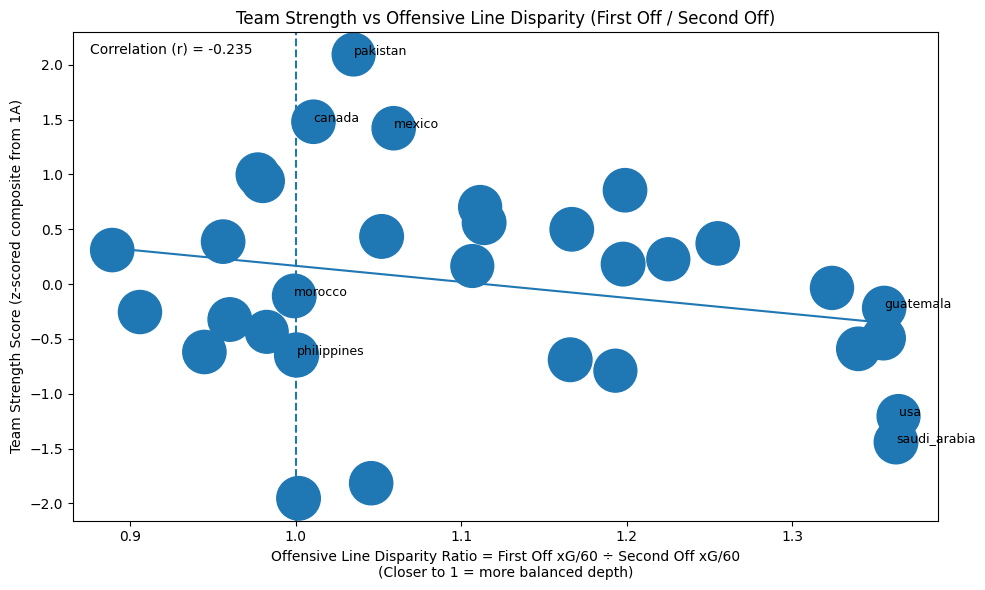

'StandardDeviants.png'

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Merge Part 1A + 1B results ---
viz = (
    team_table[["team", "strength_score", "xg_diff", "goal_diff", "win_pct"]]
    .merge(
        piv_filtered[["team", "disparity_ratio", "first_off_xg60", "second_off_xg60", "off_toi_min"]],
        on="team",
        how="inner"
    )
    .dropna(subset=["strength_score", "disparity_ratio"])
    .copy()
)

# --- 2) Compute correlation (simple, interpretable) ---
corr = np.corrcoef(viz["disparity_ratio"], viz["strength_score"])[0, 1]

# --- 3) Fit a simple trend line (least squares) ---
x = viz["disparity_ratio"].values
y = viz["strength_score"].values
m, b = np.polyfit(x, y, 1)  # y = m*x + b

# --- 4) Choose a few teams to label (keeps plot readable) ---
# Label: top 3 strongest, top 3 disparity, and 2 most balanced (closest to 1)
label_teams = set()

label_teams.update(viz.nlargest(3, "strength_score")["team"].tolist())
label_teams.update(viz.nlargest(3, "disparity_ratio")["team"].tolist())
viz["abs_balance"] = (viz["disparity_ratio"] - 1).abs()
label_teams.update(viz.nsmallest(2, "abs_balance")["team"].tolist())

# --- 5) Make the plot ---
plt.figure(figsize=(10, 6))

# Bubble size optional: scale by offensive TOI so more reliable teams appear slightly larger
# (If you don’t want bubbles, replace s=... with a constant like s=40)
sizes = 30 + 2 * np.sqrt(viz["off_toi_min"].values)

plt.scatter(viz["disparity_ratio"], viz["strength_score"], s=sizes)

# Trend line
x_line = np.linspace(viz["disparity_ratio"].min(), viz["disparity_ratio"].max(), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line)

# Reference line at disparity=1 (balanced lines)
plt.axvline(1.0, linestyle="--")

# Titles / labels / caption text
plt.title("Team Strength vs Offensive Line Disparity (First Off / Second Off)")
plt.xlabel("Offensive Line Disparity Ratio = First Off xG/60 ÷ Second Off xG/60\n(Closer to 1 = more balanced depth)")
plt.ylabel("Team Strength Score (z-scored composite from 1A)")

# Put correlation in the corner
plt.text(
    0.02, 0.98,
    f"Correlation (r) = {corr:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

# Label selected teams
for _, r in viz[viz["team"].isin(label_teams)].iterrows():
    plt.text(r["disparity_ratio"], r["strength_score"], str(r["team"]), fontsize=9)

plt.tight_layout()

# --- 6) Save as PNG (title with your team name, no spaces) ---
out_name = "StandardDeviants.png"  # IMPORTANT: no spaces, per instructions
plt.savefig(out_name, dpi=200)
plt.show()

out_name